# K-Means Clustering on the Iris Dataset

This colab friendly notebook demonstrates the K-Means clustering algorithm on the standard Iris dataset. It uses the Elbow Method to determine the optimal number of clusters. Distance is calculated using Euclidean distance, which is fancy way of saying the straight-line distance between two points in space... just in hyperdimensional space(!)
> Always remember that you should set your k based on your domain knowledge and your knowldge of your data. The Elbow Method is just a heuristic, not a definitive answer. Use your critical thinking skills!!!

In [1]:
%pip install -q matplotlib numpy scikit-learn

print('Packages installed.')

Note: you may need to restart the kernel to use updated packages.
Packages installed.


## Imports and setup

The script uses the built-in Iris dataset from `scikit-learn`, and the standard plotting utilities for a quick visual check.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

np.random.seed(42)

print('Libraries imported.')

Libraries imported.


## Load the dataset and evaluate the elbow

We test a range of cluster counts from 1 to 10 and inspect the inertia values. The elbow point is a heuristic signal for choosing a reasonable `k`.

In [3]:
# Set your k value
# For this dataset, the correct k is 3
k = 3

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Using all 4 features: sepal/petal length and width

# Calculate inertia for the Elbow Method (k from 1 to 10)
inertia = []
k_range = range(1, 11)

for k_value in k_range:
    kmeans = KMeans(n_clusters=k_value, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

print('Inertia values for k = 1 to 10:')
for k_value, score in zip(k_range, inertia):
    print(f'k={k_value}: inertia={score:.2f}')

Inertia values for k = 1 to 10:
k=1: inertia=681.37
k=2: inertia=152.35
k=3: inertia=78.86
k=4: inertia=57.35
k=5: inertia=46.47
k=6: inertia=39.07
k=7: inertia=34.31
k=8: inertia=30.48
k=9: inertia=29.91
k=10: inertia=28.55


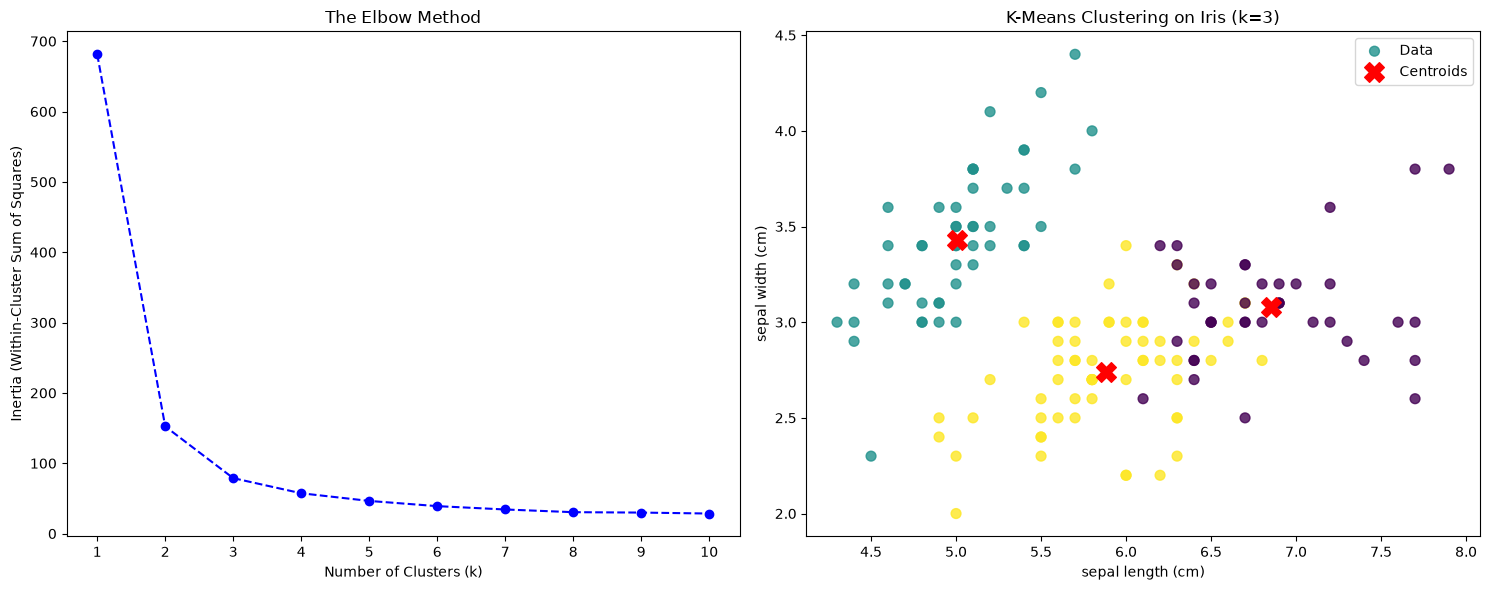

In [4]:
# Visualize the elbow plot and final cluster results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Elbow plot
ax1.plot(k_range, inertia, marker='o', linestyle='--', color='b')
ax1.set_title('The Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax1.set_xticks(k_range)

# Fit the final model using the chosen k value
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
y_kmeans = final_kmeans.fit_predict(X)

# Plot the first two features (Sepal Length vs Sepal Width)
ax2.scatter(
    X[:, 0],
    X[:, 1],
    c=y_kmeans,
    s=50,
    cmap='viridis',
    alpha=0.8,
    label='Data'
)

# Plot centroids
centroids = final_kmeans.cluster_centers_
ax2.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

ax2.set_title('K-Means Clustering on Iris (k=3)')
ax2.set_xlabel(iris.feature_names[0])
ax2.set_ylabel(iris.feature_names[1])
ax2.legend()

plt.tight_layout()
plt.show()

## Final cluster output

The final section prints the actual grouped points by cluster so you can inspect the results from the model.

In [4]:
print('Final K-Means Clustering Results:')
for i in range(k):
    cluster_points = X[y_kmeans == i]
    print(f'\nCluster {i + 1}:')
    print(cluster_points)
    print(f'Type of first point in cluster {i + 1}: {type(cluster_points[0])}')

Final K-Means Clustering Results:

Cluster 1:
[[7.  3.2 4.7 1.4]
 [6.9 3.1 4.9 1.5]
 [6.7 3.  5.  1.7]
 [6.3 3.3 6.  2.5]
 [7.1 3.  5.9 2.1]
 [6.3 2.9 5.6 1.8]
 [6.5 3.  5.8 2.2]
 [7.6 3.  6.6 2.1]
 [7.3 2.9 6.3 1.8]
 [6.7 2.5 5.8 1.8]
 [7.2 3.6 6.1 2.5]
 [6.5 3.2 5.1 2. ]
 [6.4 2.7 5.3 1.9]
 [6.8 3.  5.5 2.1]
 [6.4 3.2 5.3 2.3]
 [6.5 3.  5.5 1.8]
 [7.7 3.8 6.7 2.2]
 [7.7 2.6 6.9 2.3]
 [6.9 3.2 5.7 2.3]
 [7.7 2.8 6.7 2. ]
 [6.7 3.3 5.7 2.1]
 [7.2 3.2 6.  1.8]
 [6.4 2.8 5.6 2.1]
 [7.2 3.  5.8 1.6]
 [7.4 2.8 6.1 1.9]
 [7.9 3.8 6.4 2. ]
 [6.4 2.8 5.6 2.2]
 [6.1 2.6 5.6 1.4]
 [7.7 3.  6.1 2.3]
 [6.3 3.4 5.6 2.4]
 [6.4 3.1 5.5 1.8]
 [6.9 3.1 5.4 2.1]
 [6.7 3.1 5.6 2.4]
 [6.9 3.1 5.1 2.3]
 [6.8 3.2 5.9 2.3]
 [6.7 3.3 5.7 2.5]
 [6.7 3.  5.2 2.3]
 [6.5 3.  5.2 2. ]
 [6.2 3.4 5.4 2.3]]
Type of first point in cluster 1: <class 'numpy.ndarray'>

Cluster 2:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4